In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

df = pd.read_csv('netflix_titles.csv',encoding='latin1')

BASIC UNDERSTANDING

In [56]:
print("Dataset Shape:",df.shape)
print("Dataset coloumns:",df.columns)
print(df.isnull().sum())

Dataset Shape: (8807, 12)
Dataset coloumns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


Data Cleaning

In [57]:
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

Content Type Analysis

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\46725528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=content_type.index,y=content_type.values,palette='viridis')


Text(0, 0.5, 'Count')

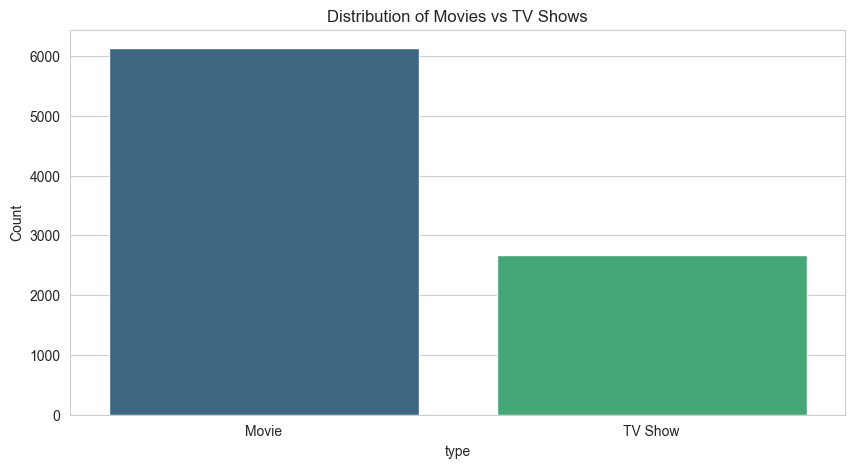

In [58]:
content_type = df['type'].value_counts()
sns.barplot(x=content_type.index,y=content_type.values,palette='viridis')
plt.title('Distribution of Movies vs TV Shows')
plt.ylabel('Count')

Country Analysis

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\1251487100.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='cividis')


Text(0, 0.5, 'Country')

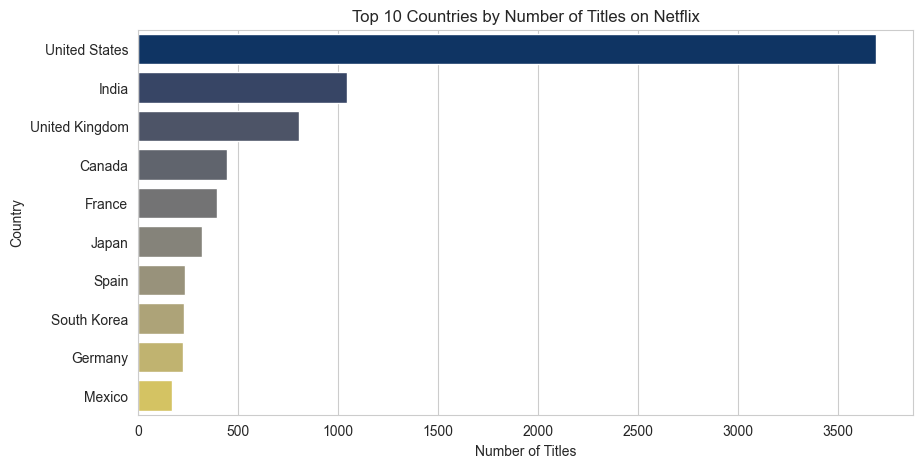

In [59]:
countries = df['country'].str.split(',').explode().str.strip()
countries = countries[countries != 'Not Specified']
top_countries = countries.value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='cividis')
plt.title('Top 10 Countries by Number of Titles on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

Year-wise Trend

Text(0, 0.5, 'Number of Titles')

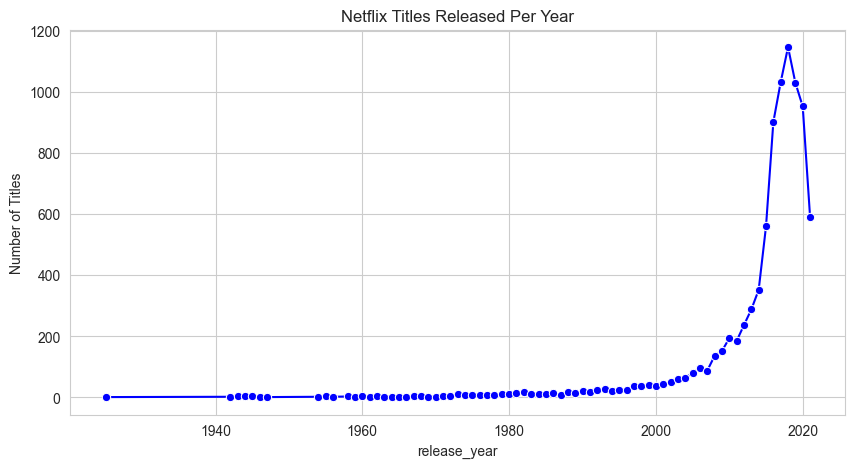

In [60]:
titles_per_year = df['release_year'].value_counts().sort_index()
sns.lineplot(x=titles_per_year.index,y=titles_per_year.values,marker='o',color='blue')
plt.title('Netflix Titles Released Per Year')
plt.ylabel('Number of Titles')

Top Countries Producing TV Shows vs Movies

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\1633731683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=more_tv['TV Show'], y=more_tv.index, palette='coolwarm')


<Axes: xlabel='TV Show', ylabel='country'>

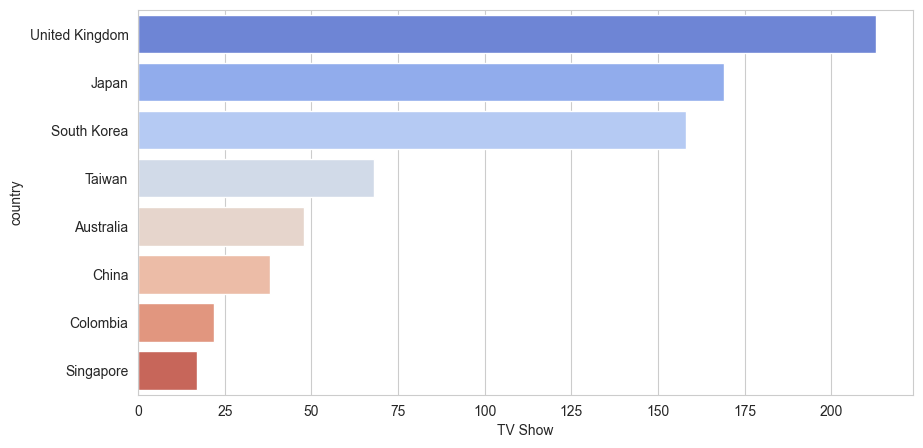

In [61]:
country_type = df.groupby(['country','type']).size().unstack().fillna(0)
more_tv = country_type[country_type['TV Show'] > country_type['Movie']].sort_values('TV Show',ascending=False).head(8)
sns.barplot(x=more_tv['TV Show'], y=more_tv.index, palette='coolwarm')

Movie vs TV Show Growth Over Years

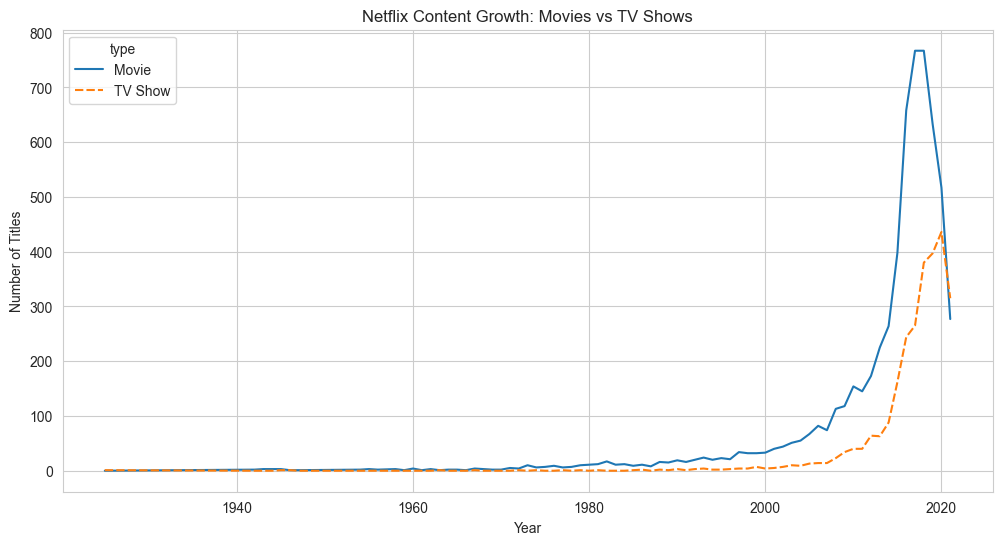

In [62]:
titles_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

plt.figure(figsize=(12,6))
sns.lineplot(data=titles_year)
plt.title("Netflix Content Growth: Movies vs TV Shows")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


Rating Analysis

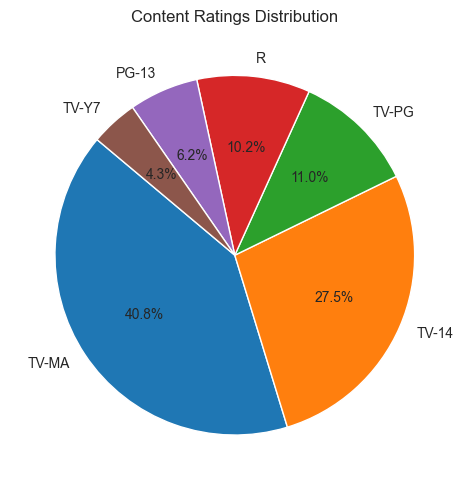

In [63]:
ratings = df['rating'].value_counts().head(6)
plt.figure(figsize=(8,5))
plt.pie(ratings.values,labels=ratings.index,autopct='%1.1f%%',startangle=140)
plt.title('Content Ratings Distribution')
plt.tight_layout()

Director Analysis

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\2151528625.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='magma')


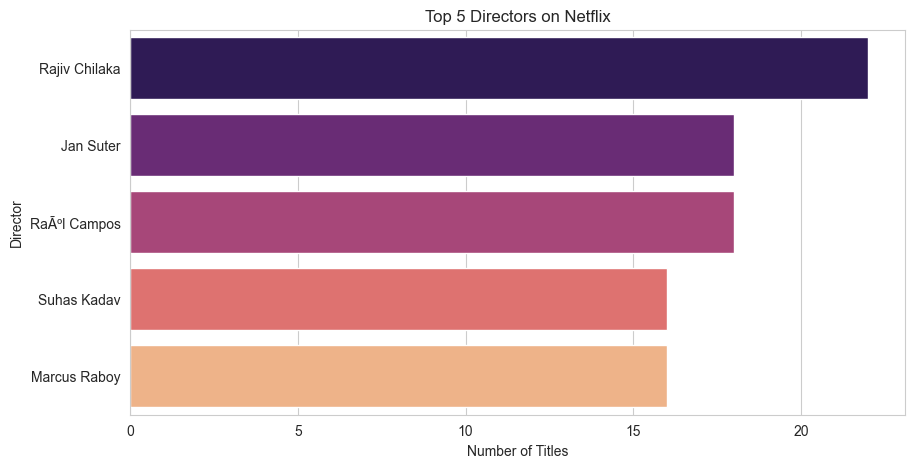

In [64]:
directors = df['director'].str.split(',').explode()
directors = directors[directors != 'Not Specified']
top_directors = directors.value_counts().head(5)

sns.barplot(x=top_directors.values, y=top_directors.index, palette='magma')
plt.title('Top 5 Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

Actor / Cast Analysis

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\238526162.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values,y=top_actors.index,palette='cool')


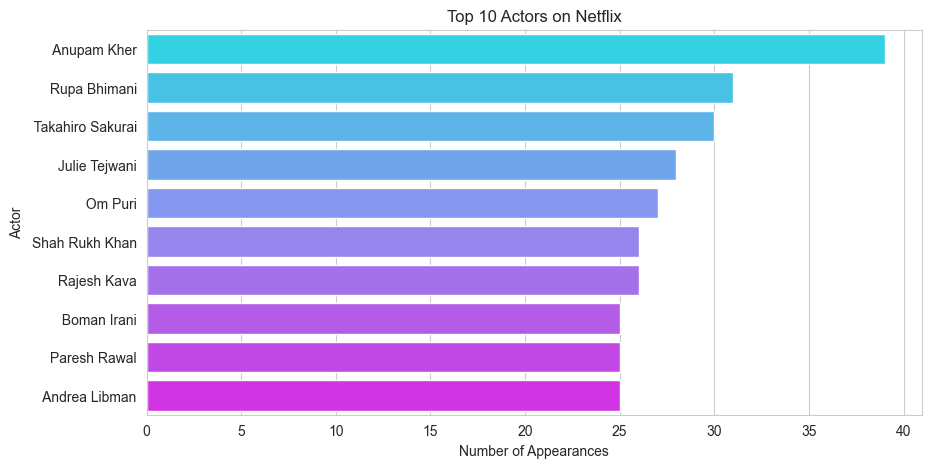

In [65]:
actors = df['cast'].str.split(',').explode()
actors = actors[actors != 'Not Specified']
top_actors = actors.value_counts().head(10)

sns.barplot(x=top_actors.values,y=top_actors.index,palette='cool')
plt.title('Top 10 Actors on Netflix')
plt.xlabel('Number of Appearances')
plt.ylabel('Actor')
plt.show()

Duration Analysis

In [66]:
movies = df[df['type'] == 'Movie'].copy()
movies = movies[movies['duration'].str.contains('min', na=False)]
movies['duration_min'] = movies['duration'].str.replace(' min','').astype(int)

avg_duration = movies['duration_min'].mean()
print(f"Average movie duration: {avg_duration:.2f} minutes")

most_common_duration = movies['duration_min'].mode()[0]
print(f"The most common movie duration is {most_common_duration} minutes")

longest_duration = movies['duration_min'].max()
print(f"The longest movie duration is {longest_duration} minutes")


Average movie duration: 99.58 minutes
The most common movie duration is 90 minutes
The longest movie duration is 312 minutes


Genre Analysis

C:\Users\PMLS\AppData\Local\Temp\ipykernel_42168\3191091084.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values,y=top_genres.index,palette='Spectral')


Text(0.5, 0, 'Number of titles')

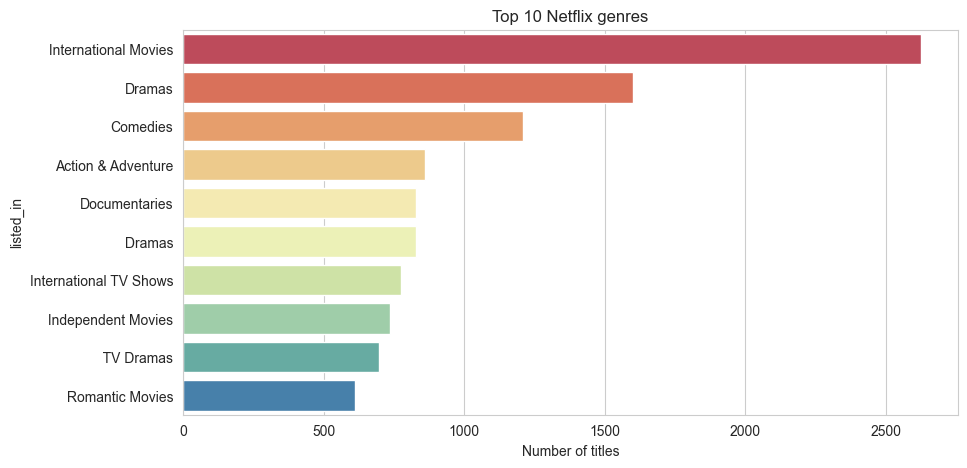

In [67]:
genre = df['listed_in'].str.split(',').explode()
top_genres = genre.value_counts().head(10)

sns.barplot(x=top_genres.values,y=top_genres.index,palette='Spectral')
plt.title('Top 10 Netflix genres')
plt.xlabel('Number of titles')
